In [ ]:
try:
    import firedrake
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-release-real.sh" -O "/tmp/firedrake-install.sh" && bash "/tmp/firedrake-install.sh"
    import firedrake

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [1]:
from firedrake import *
import matplotlib.pyplot as plt
import numpy as np

from firedrake.petsc import PETSc

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


In [2]:
# Get current path: all relative paths that you may use for input/output start from here.
#
# - Colab:  The default path is /content, and your GDrive folder is accessible (if mounted) at /content/drive/MyDrive
#
# - local:  If running on your local machine, current_path is the position WHERE YOU LAUNCHED THE NOTEBOOK KERNEL BY 'jupyter notebook'
#           and NOT the directory in which this ipynb file is saved.
#           If you want to modify your current path, go to the terminal, stop the kernel (ctrl-C + press y), then move to the desired path by
#           cd my/desired/path/starting/from/here
#           and then launch 'jupyter notebook'.
import os
current_path = os.getcwd()
print(current_path)
my_io_path = current_path + "/cfd-labs/Lab09-Stabilizations/" 
# my_io_path = current_path+"/"
print(my_io_path)

/home/aless
/home/aless/cfd-labs/Lab09-Stabilizations/


---
---
# Exercise 1

\begin{equation*}
\begin{cases}
(\boldsymbol{u}\cdot\nabla)\boldsymbol{u} - \frac{1}{\rm Re}(\nabla \boldsymbol{u} +\nabla \boldsymbol{u} ^T)+ \nabla  p  = \boldsymbol{0} & {\rm in} \ \Omega, \\
{\rm div}\,\boldsymbol{u} = 0 & {\rm in} \ \Omega, \\
\boldsymbol{u} = \boldsymbol{i} & {\rm on} \ \Gamma_{\rm up}, \\
\boldsymbol{u} = \boldsymbol{0} & {\rm on}\ \Gamma_{\rm wall}=\partial\Omega\setminus\Gamma_{\rm up}, \\
\end{cases}
\end{equation*}

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?


/home/aless/.local/share/mamba/envs/firedrake/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/aless/.local/share/mamba/envs/firedrake/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


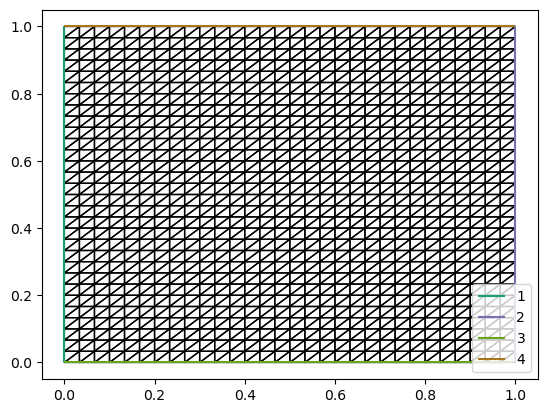

In [19]:
# Build the mesh
n = 30
mesh = UnitSquareMesh(n, n, diagonal='right')

# # Move mesh vertices
# x = SpatialCoordinate(mesh)
# Vc = mesh.coordinates.function_space()
# mf = Function(Vc).interpolate(as_vector([(1-cos(pi*x[0]))/2, (1-cos(pi*x[1]))/2]))
# mesh.coordinates.assign(mf)  # evaluates mf on the mesh nodes x_i and assigns new nodes positions mf(x_i)

fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend()

In [20]:
# Function spaces (mixed formulation)
V = VectorFunctionSpace(mesh, 'P', 1)
Q = FunctionSpace(mesh, 'P', 1)
W = MixedFunctionSpace([V, Q])

# Data and boundary conditions
Re = 3000.0
f = Constant((0.,0.))
x = SpatialCoordinate(mesh)

bc_lid = DirichletBC(W.sub(0), Constant((1.0,0.0)), 4)
bc_wall = DirichletBC(W.sub(0), Constant((0.0,0.0)), (1,2,3))

bcs = (bc_wall, bc_lid)

# Handle the pressure indetermination by specifying the nullspace
nsp = MixedVectorSpaceBasis(
    W, [W.sub(0), VectorSpaceBasis(constant=True)]
)

firedrake:WARNING No comm specified for VectorSpaceBasis, COMM_WORLD assumed


### Variational problems

In [21]:
u, p = TrialFunctions(W)
v, q = TestFunctions(W)

def nonlinear_iteration_forms(u, v, p, q, Re, f, u_old):
    # Picard iteration
    a_fp = (
        Constant(1.0/Re)*inner(grad(u), grad(v)) * dx
        + inner(dot(grad(u), u_old), v) * dx
        - p * div(v) * dx
        + q * div(u) * dx
    )
    L_fp = (
        inner(f, v) * dx
    )

    return a_fp, L_fp

def BrezziPitkaranta(u, v, p, q, Re, f, u_old, delta_K):
    lhs_BP = delta_K * inner(grad(p), grad(q)) * dx
        # since delta_K is p-w const -> integral is automatically split
    rhs_BP = Constant(0)*q * dx # or, equivalently, inner(Constant((0,0)),v)*dx

    return lhs_BP, rhs_BP

def SUPG(u, v, p, q, Re, f, u_old, delta_K):
    print(norm(delta_K), flush=True)
    # SUPG-stabilization of Picard iteration
    lhs_fpSUPG = delta_K * inner(
            -1.0/Re*div(grad(u))
                + dot(grad(u), u_old)# + 0.5*div(u_old)*u
                + grad(p)
            ,
            dot(grad(v), u_old) + 0.5*div(u_old)*v
            + grad(q)
            ) * dx \
            + delta_K * div(u) * div(v) * dx
    rhs_fpSUPG = Constant(0)*q * dx # or, equivalently, inner(Constant((0,0)),v)*dx

    return lhs_fpSUPG, rhs_fpSUPG

### Initialization and definition of the ***linear*** solver for each nonlinear iteration.

In [22]:
# Initialization (wh = 0)
wh = Function(W)
wh.interpolate(Constant((0.0,0.0,0.0)))
uh, ph = wh.subfunctions

# Nonlinear solver
u_old = Function(V)
u_old.assign(uh)    # copy the dof's of uh (defined over W) into u_old (defined over V)
                    # Do not use 'u_old = uh', which would yield a "shallow copy", by which
                    # u_old would contain a sort of pointer to uh: in such case, any update of uh
                    # would immediately reflect on u_old, whilst we want to keep the two functions
                    # separate from one another, and update them only when actually intended.
p_old = Function(Q)
p_old.assign(ph)

a, L = nonlinear_iteration_forms(u, v, p, q, Re, f, u_old)

USE_SUPG = True    # choose wether to use SUPG:
                   # a single variable to control this everywhere, to ensure consistency between code and output filename

# Stabilization coefficient
delta = 0.01
delta_K = Function(FunctionSpace(mesh, 'DG', 0))  # piecewise constant
delta_K.rename("delta_K")
h = CellDiameter(mesh)

# Brezzi-Pitkaranta
delta_K.project(delta * h*h*Re)
# delta_K = delta * h*h*Re

# SUPG
ubar = Function(FunctionSpace(mesh, 'DG', 0)) # piecewise constant Function
ubar.project(sqrt(inner(u_old, u_old)))
if USE_SUPG:
  delta = 0.01
  delta_K.project(delta * conditional(
                            gt(h * ubar * Re, 1.0),
                            h/(ubar+1e-5),
                            h*h*Re))

In [23]:
# vtk output for Paraview
basename = 'lab09_ex1_Re' + str(int(Re))
print(basename)
if USE_SUPG:
    basename = basename + '_SUPG'

# vtk output for Paraview
outfileU = File(my_io_path+"output/"+basename+"velocity.pvd")
outfileP = File(my_io_path+"output/"+basename+"pressure.pvd")
uh.rename("Velocity")   # this name will be used in Paraview
ph.rename("Pressure")   # this name will be used in Paraview
outfileU.write(uh)
outfileP.write(ph)

lab09_ex1_Re3000


NameError: name 'File' is not defined

### Iterative algorithm for the solution of the nonlinear problem

In [ ]:
maxit = 100
it = 0
tol = 1e-3
err = tol+1     # >tol in order to enter the loop at the beginning

a, L = nonlinear_iteration_forms(u, v, p, q, Re, f, u_old)
vpb = LinearVariationalProblem(a, L, wh, bcs=bcs)

if USE_SUPG:
  lhs_stabilization, rhs_stabilization = SUPG(u, v, p, q, Re, f, u_old, delta_K)
else:
  lhs_stabilization, rhs_stabilization = BrezziPitkaranta(u, v, p, q, Re, f, u_old, delta_K)
vpb = LinearVariationalProblem(a+lhs_stabilization, L+rhs_stabilization, wh, bcs=bcs)

param = {'ksp_type': 'preonly', 'pc_type': 'lu', 'pc_factor_mat_solver_type': 'mumps'}
solver = LinearVariationalSolver(vpb, nullspace=nsp, solver_parameters=param)

while it <= maxit and err > tol:

    it += 1
    print("Iteration = ", it, flush=True)

    if USE_SUPG:
      # update delta_K for SUPG
      ubar.project(sqrt(inner(u_old, u_old)))
      delta_K.project(delta * conditional(
                                gt(h * ubar * Re, 1.0),
                                h/(ubar+1e-5),
                                h*h*Re))
      print("presumably updated norm of deltaK: ", norm(delta_K))
      print("  actually updated norm of deltaK: ",[norm(c) for c in vpb.J.coefficients() if c.name()=='delta_K'][0], flush=True)

    solver.solve()

    uh, ph = wh.subfunctions

    err = (errornorm(uh, u_old, 'H1') / norm(u_old, 'H1') +
           errornorm(ph, p_old, 'L2') / norm(p_old, 'L2'))
    err_u = errornorm(uh, u_old, 'H1') / norm(u_old, 'H1')
    err_p = errornorm(ph, p_old, 'L2') / norm(p_old, 'L2')

    print(errornorm(uh, u_old, 'H1') , norm(u_old, 'H1'),"\t Increments = ", err, '(total)    ', err_u, '(u)    ', err_p, '(p)', flush=True)
    uh.rename("Velocity")
    ph.rename("Pressure")
    outfileU.write(uh)
    outfileP.write(ph)

    u_old.assign(uh) # update the old solution
    p_old.assign(ph) # update the old solution

if it <= maxit:
    print('Nonlinear solver converged in', it, 'iterations.')
else:
    print('Nonlinear solver did NOT converge!\nRelative error =', err, 'after', it, 'iterations.')

0.06666666666666682
Iteration =  1
presumably updated norm of deltaK:  0.06666666666666682
  actually updated norm of deltaK:  0.06666666666666682
3.780783193781643 0.0 	 Increments =  inf (total)     inf (u)     inf (p)
Iteration =  2
presumably updated norm of deltaK:  0.020185146090280947
  actually updated norm of deltaK:  0.020185146090280947


/tmp/ipykernel_254286/444542586.py:37: RuntimeWarning: divide by zero encountered in scalar divide
  err = (errornorm(uh, u_old, 'H1') / norm(u_old, 'H1') +
/tmp/ipykernel_254286/444542586.py:38: RuntimeWarning: divide by zero encountered in scalar divide
  errornorm(ph, p_old, 'L2') / norm(p_old, 'L2'))
/tmp/ipykernel_254286/444542586.py:39: RuntimeWarning: divide by zero encountered in scalar divide
  err_u = errornorm(uh, u_old, 'H1') / norm(u_old, 'H1')
/tmp/ipykernel_254286/444542586.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  err_p = errornorm(ph, p_old, 'L2') / norm(p_old, 'L2')


2.641597645871105 3.780783193781643 	 Increments =  5.723203813189307 (total)     0.6986905914668189 (u)     5.024513221722488 (p)
Iteration =  3
presumably updated norm of deltaK:  0.015662986420233588
  actually updated norm of deltaK:  0.015662986420233588
1.584322862985526 4.994446471126465 	 Increments =  0.8987697889322264 (total)     0.31721690724782003 (u)     0.5815528816844063 (p)
Iteration =  4
presumably updated norm of deltaK:  0.018756876617610982
  actually updated norm of deltaK:  0.018756876617610982
0.8523215570608351 4.469357017589505 	 Increments =  0.5721684215549194 (total)     0.19070339507594866 (u)     0.38146502647897074 (p)
Iteration =  5
presumably updated norm of deltaK:  0.018106541402116805
  actually updated norm of deltaK:  0.018106541402116805
0.48460288713287336 4.615661167284996 	 Increments =  0.2395838906142826 (total)     0.10499100119559347 (u)     0.13459288941868913 (p)
Iteration =  6
presumably updated norm of deltaK:  0.018856584217740023
  a

Text(0.5, 1.0, 'velocity')

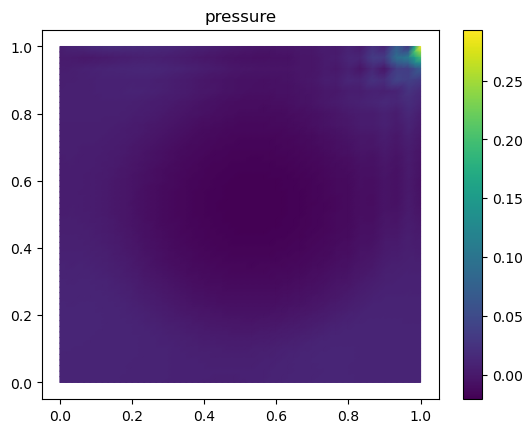

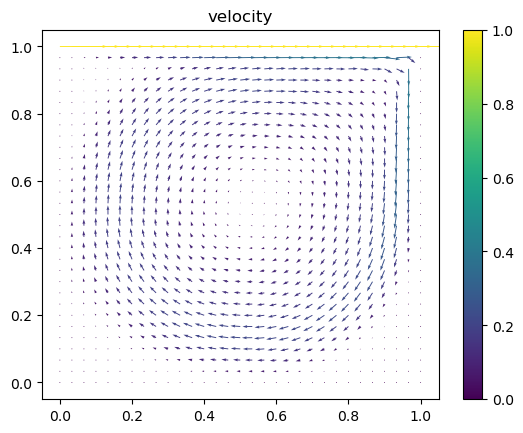

In [26]:
fig, ax = plt.subplots()
col = tripcolor(p_old, axes=ax)
plt.colorbar(col)
plt.title('pressure')
fig, ax = plt.subplots()
col = quiver(u_old, axes=ax)
plt.colorbar(col)
plt.title('velocity')

---
---
# Exercise 2 - homework (inspired by CFDlab08)

In [ ]:
# Build the mesh
n = 30
mesh = RectangleMesh(3*n, n, 3, 1)

fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend()

### Variational form - residual

In [ ]:
# inputs:   uh, ph  components of an actual Function (NOT trial functions)
#           v, q    components of a TestFunction
#           nu, f   viscosity and source function
# output:   G       linear form (i.e. functional) representing the evaluation of
#                   the residual for a given solution (uh,ph), for any test function
def nonlinear_problem_residual(uh, v, ph, q, nu, f):
    # G = inner(dot(grad(uh), uh), v) * dx  \
    #     + nu * inner(grad(uh), grad(v)) * dx  \
    #     - div(v) * ph * dx  \
    #     + q * div(uh) * dx \
    #     - inner(f, v) * dx

    G = inner(dot(grad(uh), uh), v) * dx  \
        + nu * inner(sym(grad(uh)), sym(grad(v))) * dx  \
        - div(v) * ph * dx  \
        + q * div(uh) * dx \
        - inner(f, v) * dx

    return G

### FE spaces, data, BCs

In [ ]:
# Function spaces (mixed formulation)
V = VectorFunctionSpace(mesh, 'P', 2)
Q = FunctionSpace(mesh, 'P', 1)
W = MixedFunctionSpace([V, Q])

# Data and boundary conditions
Re = 300
f = Constant((0.,0.))
x = SpatialCoordinate(mesh)

u_in = (6*x[1]*(1-x[1]), 0.)
bc_in = DirichletBC(W.sub(0), u_in, 1)

bc_noslip = DirichletBC(W.sub(0), Constant((0.,0.)), (3,4))

bc_freeslip = DirichletBC(W.sub(0).sub(1), Constant(0.), (3,4))

# bcs = (bc_in, bc_noslip)
bcs = (bc_in, bc_freeslip)

### Assembly of the residual

In [ ]:
wh = Function(W)
uh, ph = split(wh)
v, q = TestFunctions(W)
# NB:   wh (and also uh,ph) must be created before creating G.
#       If you re-define wh (or uh,ph), you MUST re-compute G,
#       since G is the evaluation of the residual on a specific wh.

# Notice that G needs to be a functional, not a bilinear form
G = nonlinear_problem_residual(uh, v, ph, q, 1.0/Re, f)
print(len(G.arguments()))   # 1: only test function

u, p = TrialFunctions(W)
print(len((inner(u,v)*dx).arguments())) # 2: trial and test functions

### Actual solution

In [ ]:
param=( {'snes_type':'newtonls', # nonlinear solver types: https://petsc.org/release/manual/snes/#the-nonlinear-solvers
       'snes_monitor':'',        # activate logging options
       'snes_monitoring_lg_residualnorm':'', # print ||G|| at each iteration
       'snes_rtol':1e-6, 'snes_atol':1e-10, 'snes_stol':1e-14, 'snes_maxit':1000,
       'ksp_rtol':1e-8
       })
solve(G == 0, wh, bcs=bcs, solver_parameters=param)

# Equivalent:
#     nlvpb = NonlinearVariationalProblem(G, wh, bcs=bcs)
#     param = ...
#     solver = NonlinearVariationalSolver(nlvpb, solver_parameters=param)
#     solver.solve()

### Stream function problem

In [ ]:
Z = FunctionSpace(mesh, 'P', 1)
psi = TrialFunction(Z)
eta = TestFunction(Z)

a_stream = inner(grad(psi), grad(eta)) * dx
# omega = Dx(uh.sub(1),0) - Dx(uh.sub(0),1)   # by components (UFL syntax)
omega = rot(uh)                               # by pre-defined UFL command
L_stream = inner( omega , eta) * dx

# # On the mesh elbow3.msh
# bc_stream_1 = DirichletBC(Z, Constant(2.0/3.0), 3)
# bc_stream_2 = DirichletBC(Z, Constant(0.0), 4)

# On the mesh elbow3bis.msh
bc_stream_1 = DirichletBC(Z, Constant(2.0/3.0), 3)
bc_stream_2 = DirichletBC(Z, Constant(0.0), 4)

bcs_stream = (bc_stream_1, bc_stream_2)

psi_h = Function(Z)
solve(a_stream == L_stream, psi_h, bcs_stream)

### Post-processing

In [ ]:
# WARNING
# uh,ph were created as split(wh), by which uh,ph are proxies to access wh:
# this is NECESSARY for the residual G to have the suitable type for Firedrake's nonlinear solver.
# For post-processing, instead, we need a more "direct" access to the FE functions
# corresponding to the velocity and pressure component of the solution:
# this is achieved by wh.subfunctions
uh_out, ph_out = wh.subfunctions

fig, ax = plt.subplots()
col = tripcolor(ph_out, axes=ax)
plt.colorbar(col)
plt.title('pressure')

fig, ax = plt.subplots()
col = quiver(uh_out, axes=ax)
plt.colorbar(col)
plt.title('velocity')

col = tricontour(psi_h) # psi_h is already a Function: do not need to extract components
plt.colorbar(col)

# vtk output for Paraview
basename = 'lab09_ex2_'
outfileU = File(my_io_path+"output/"+basename+"velocity.pvd")
outfileP = File(my_io_path+"output/"+basename+"pressure.pvd")
outfilePsi = File(my_io_path+"output/"+basename+"stream.pvd")
uh_out.rename("Velocity")   # this names will be used in Paraview
ph_out.rename("Pressure")
psi_h.rename("psi")
outfileU.write(uh_out)
outfileP.write(ph_out)
outfilePsi.write(psi_h)